# Credit Card Fraud Detection Using Machine Learning

## Project Overview

This project aims to detect fraudulent credit card transactions using machine learning techniques on a highly imbalanced dataset containing 284,807 transactions, of which only 492 (0.17%) are fraudulent.

The workflow includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing and feature scaling
- Handling class imbalance using SMOTE
- Training and evaluating Logistic Regression, Random Forest, and XGBoost models
- Hyperparameter tuning
- Feature importance analysis
- Threshold optimization

## Dataset

- Source: Kaggle Credit Card Fraud Detection Dataset
- Total Transactions: 284,807
- Fraudulent Transactions: 492
- Fraud Rate: 0.17%

## Objectives

- Analyze transaction patterns and class imbalance
- Build and compare multiple fraud detection models
- Evaluate models using Precision, Recall, F1-Score, and AUC-ROC
- Identify the most effective fraud detection approach

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/credit card fraud/creditcard.csv')

#Dataset Loading and Inspection

In [4]:
print("Dataset Shape:", df.shape)


Dataset Shape: (284807, 31)


In [5]:
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,'0'
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,'0'
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,'0'
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,'0'
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,'0'


In [6]:
print("\nNull Values:")
print(df.isnull().sum())


Null Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class      object
dtype: object


In [8]:
df['Class'] = df['Class'].astype(str).str.replace("'", "", regex=False)
df['Class'] = df['Class'].astype(int)

print(df['Class'].dtype)
print(df['Class'].value_counts())

int64
Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


#Exploratory Data Analysis

###Class Distribution

In [10]:
class_counts = df['Class'].value_counts()

print("Class Distribution:")
print(class_counts)

print("\nPercentage Distribution:")
print((class_counts / len(df) * 100).round(4))

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.8273
1     0.1727
Name: count, dtype: float64


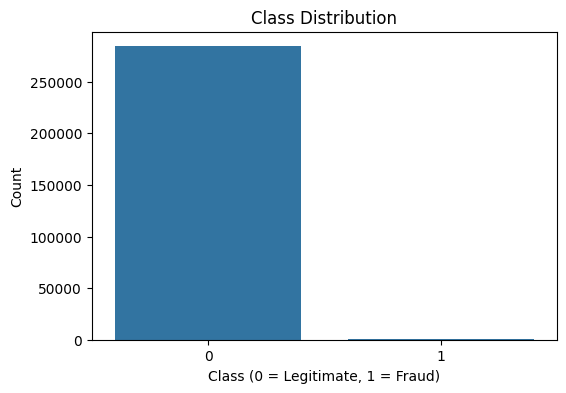

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title('Class Distribution')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')

plt.show()

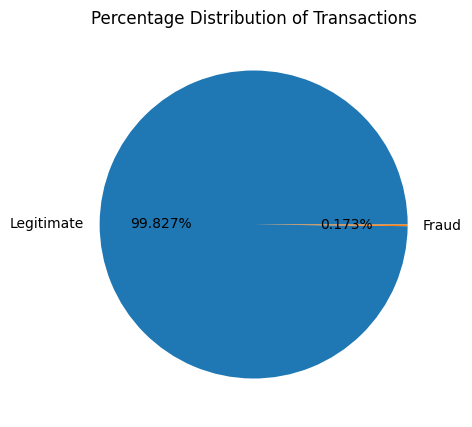

In [12]:
fraud_pct = df['Class'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(
    fraud_pct,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.3f%%'
)

plt.title('Percentage Distribution of Transactions')
plt.show()

###Correlation Analysis

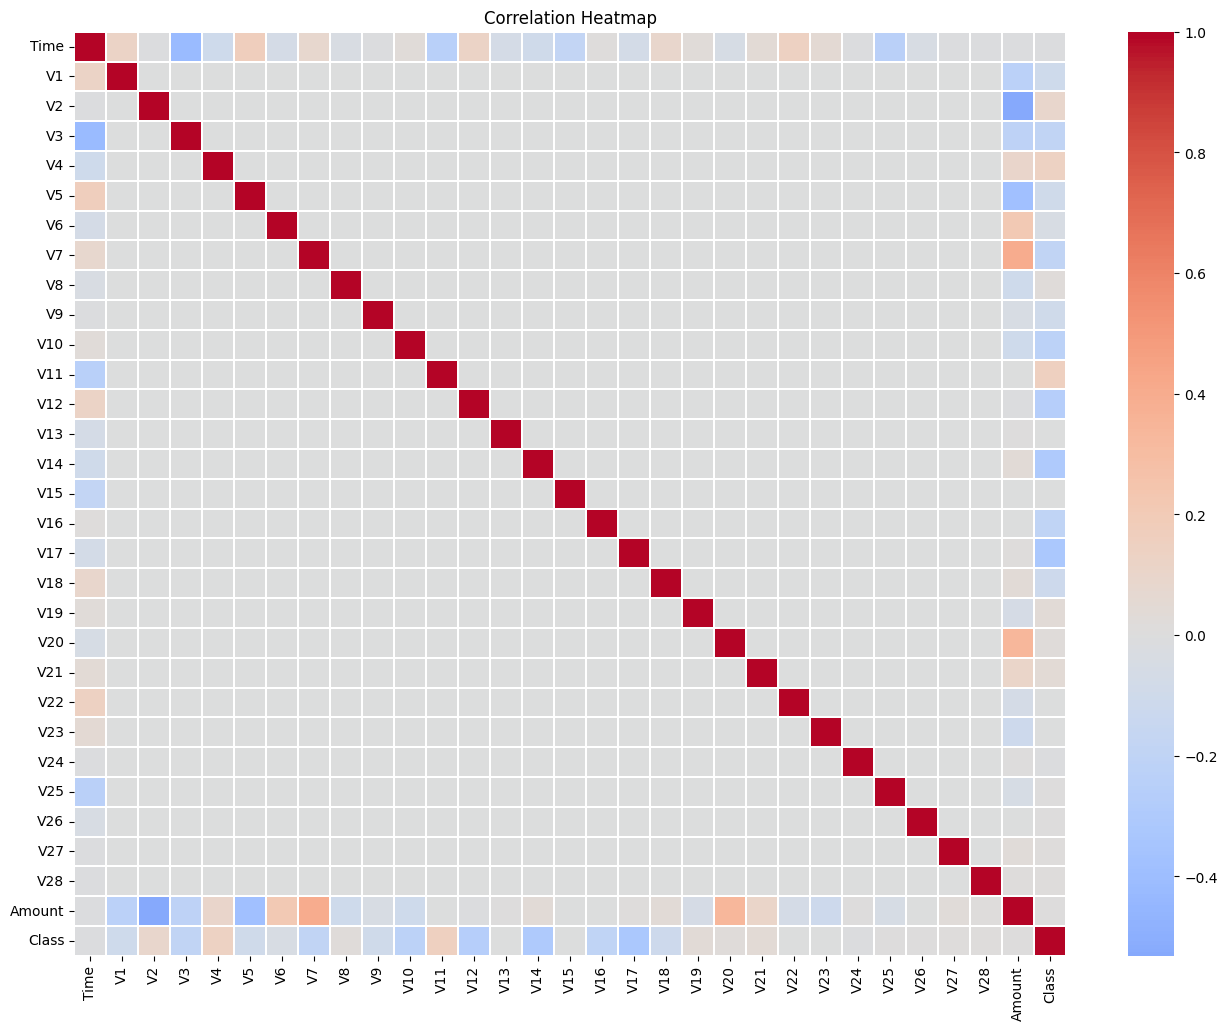

In [13]:
# Correlation matrix
corr_matrix = df.corr()
corr_matrix = df.corr()

# Heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.1
)

plt.title('Correlation Heatmap')
plt.show()

In [14]:
# Correlation with target variable
target_corr = df.corr()['Class'].sort_values(ascending=False)

print(target_corr)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


###Feature Distribution

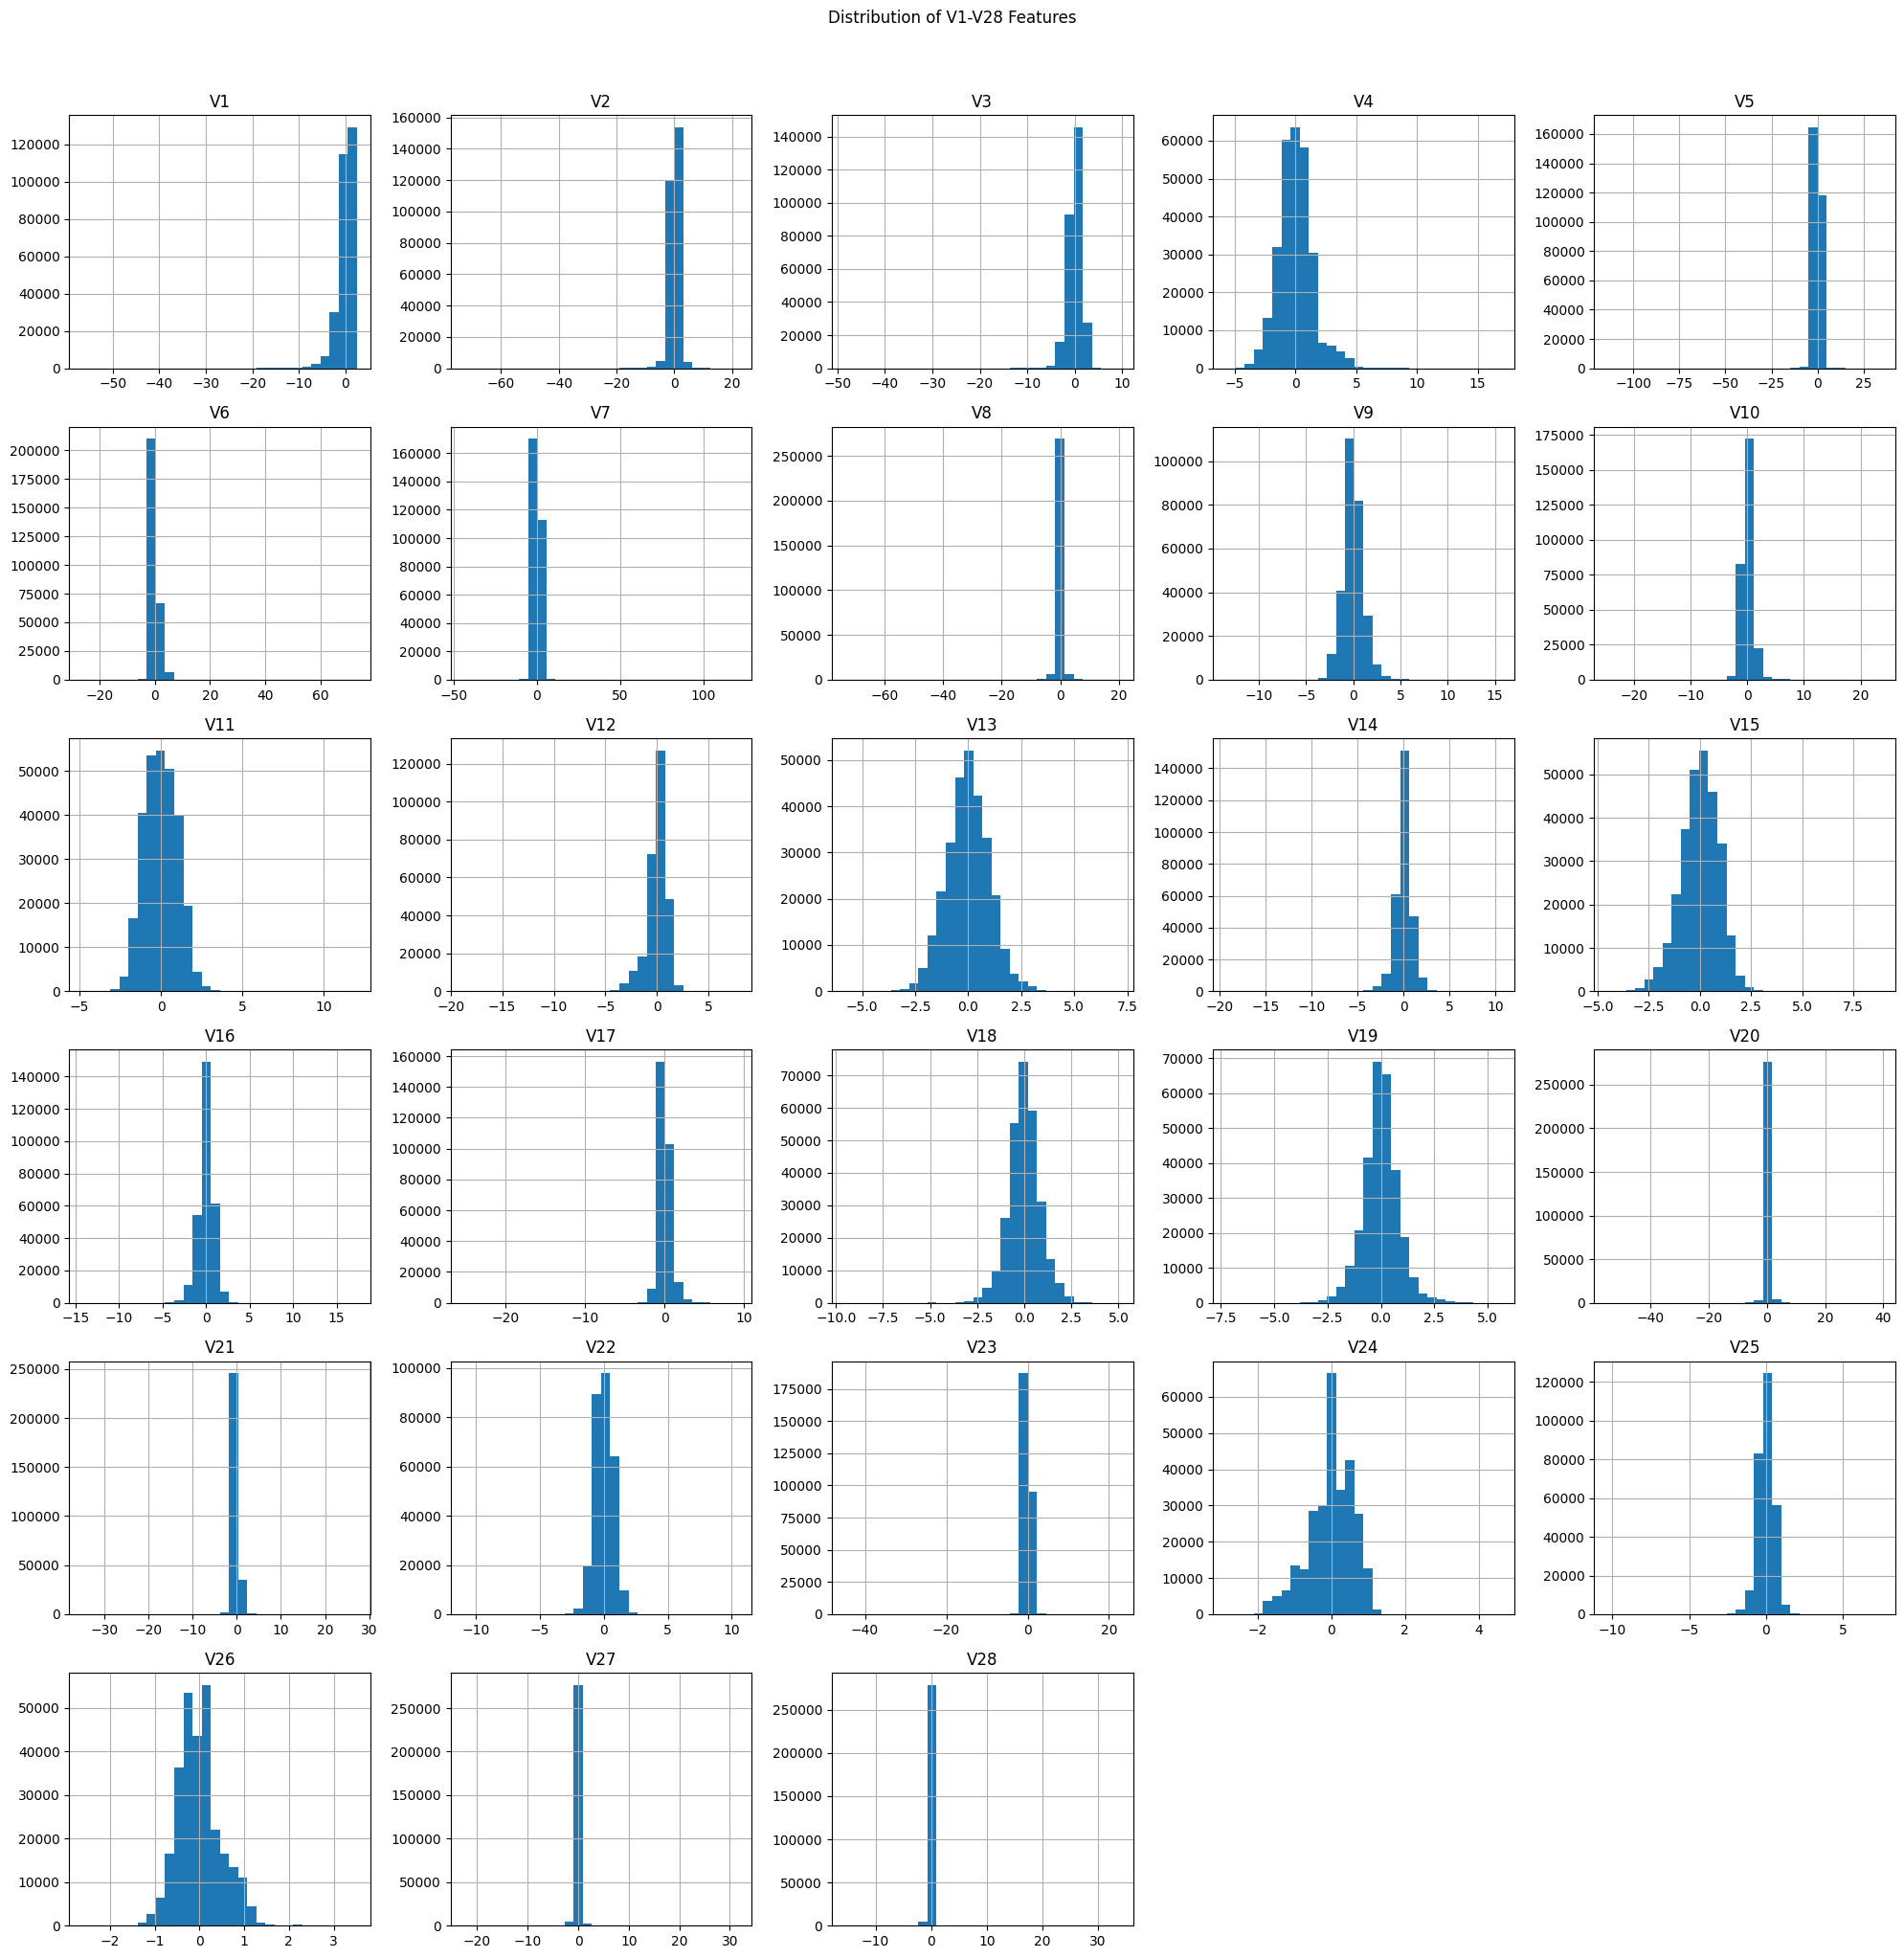

In [15]:
v_features = [f'V{i}' for i in range(1, 29)]

df[v_features].hist(
    figsize=(20,20),
    bins=30
)

plt.suptitle('Distribution of V1-V28 Features', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
top_features = [
    'V17', 'V14', 'V12', 'V10', 'V16',  # strongest negative
    'V11', 'V4', 'V2'                   # strongest positive
]

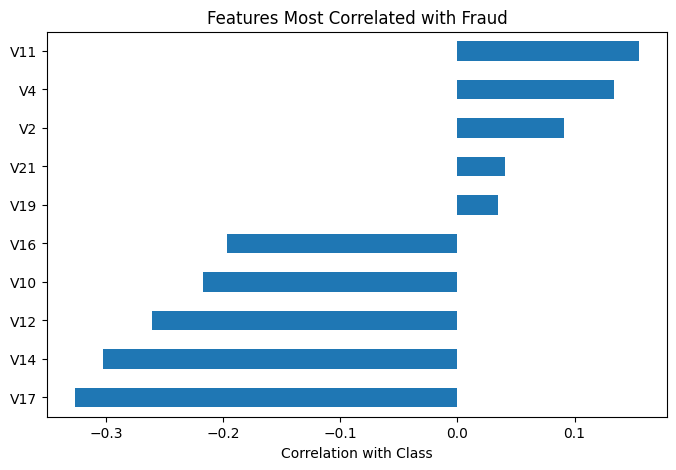

In [17]:
corr_with_target = df.corr()['Class'].drop('Class')

top_corr = pd.concat([
    corr_with_target.nlargest(5),
    corr_with_target.nsmallest(5)
])

plt.figure(figsize=(8,5))
top_corr.sort_values().plot(kind='barh')
plt.title('Features Most Correlated with Fraud')
plt.xlabel('Correlation with Class')
plt.show()

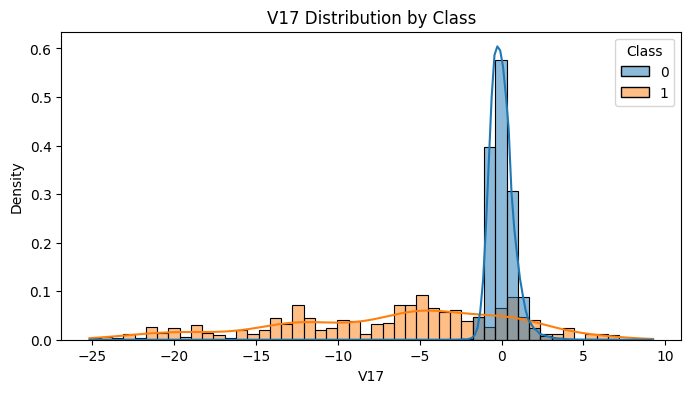

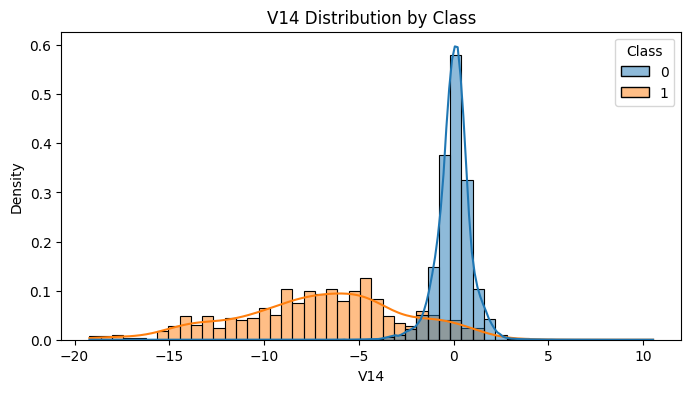

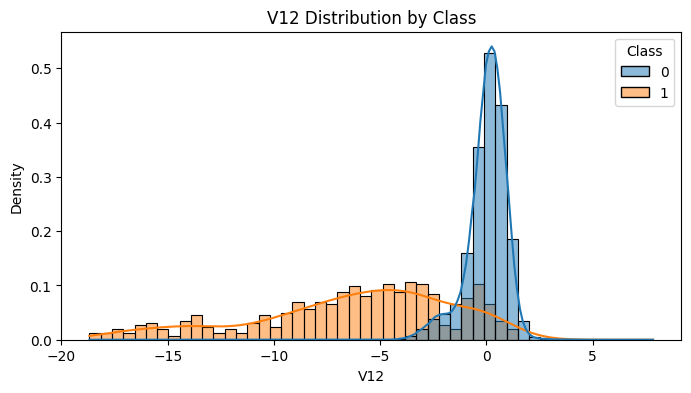

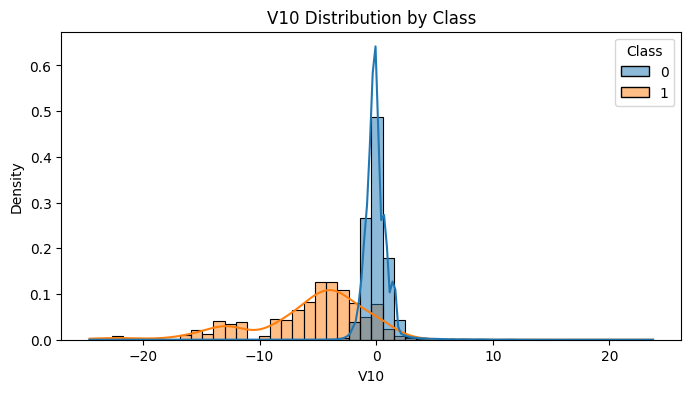

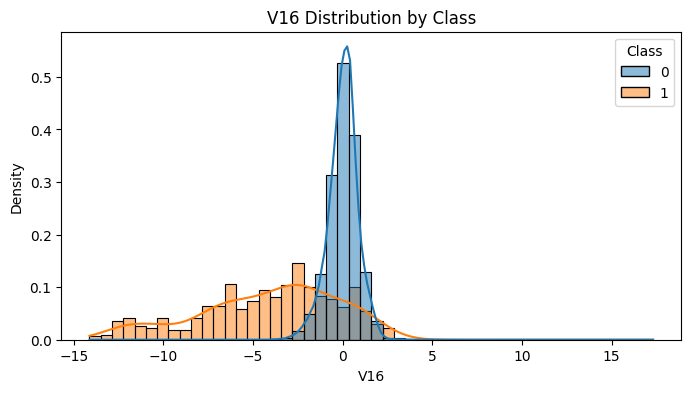

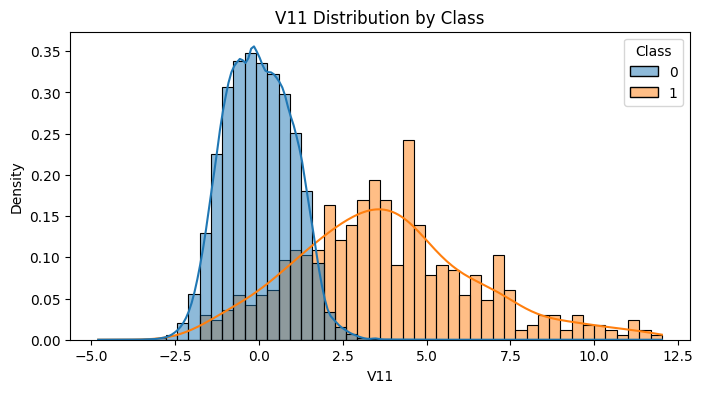

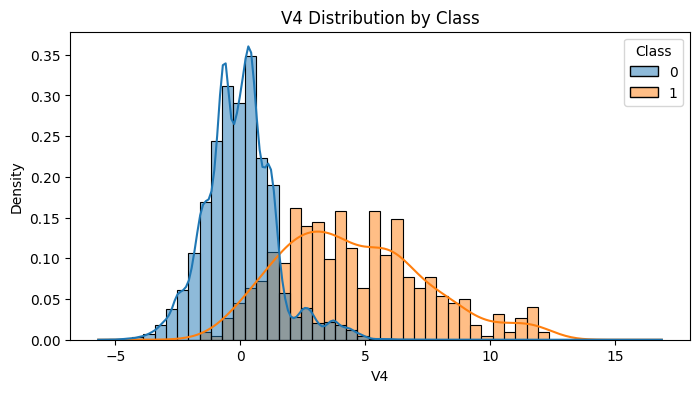

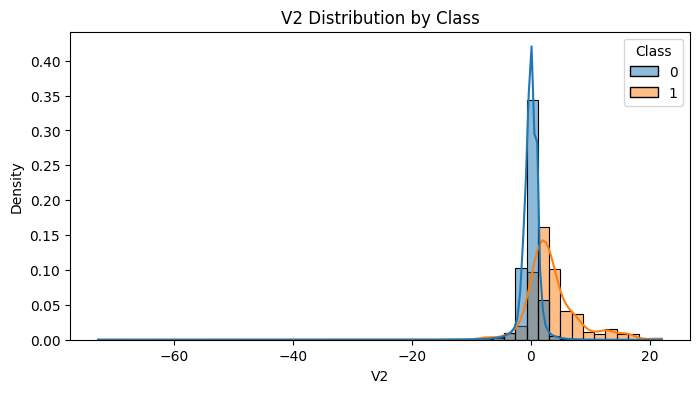

In [18]:
for feature in top_features:
    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=feature,
        hue='Class',
        bins=50,
        kde=True,
        stat='density',
        common_norm=False
    )

    plt.title(f'{feature} Distribution by Class')
    plt.show()

#Data Preprocessing

###Scaled Time and Amount using StandardScaler

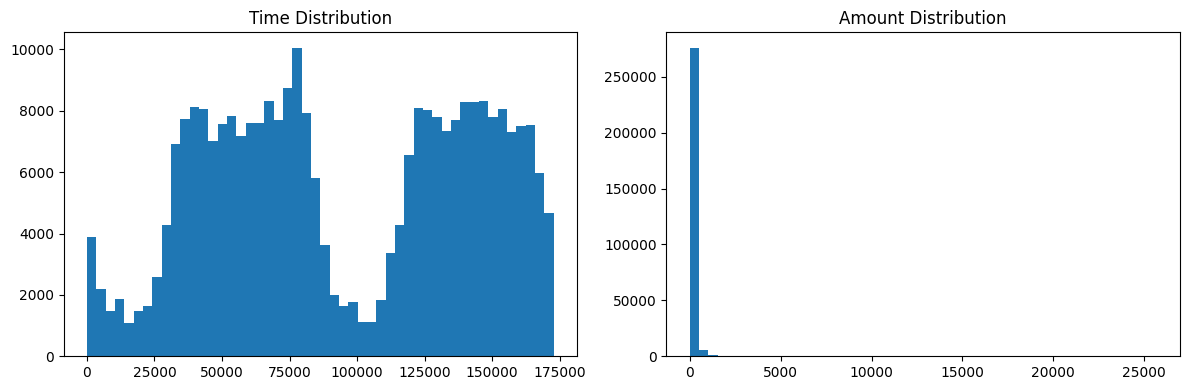

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Time'], bins=50)
axes[0].set_title('Time Distribution')

axes[1].hist(df['Amount'], bins=50)
axes[1].set_title('Amount Distribution')

plt.tight_layout()
plt.show()

In [20]:

scaler = StandardScaler()

df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

df[['Time_scaled', 'Amount_scaled']].head()

,Time_scaled,Amount_scaled
0,-1.996583,0.244964
1,-1.996583,-0.342475
2,-1.996562,1.160686
3,-1.996562,0.140534
4,-1.996541,-0.073403


In [21]:
df = df.drop(['Time', 'Amount'], axis=1)

print(df.shape)
df.head()

(284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Time_scaled,Amount_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996562,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-1.996562,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-1.996541,-0.073403


In [22]:
print(df[['Time_scaled', 'Amount_scaled']].describe())

        Time_scaled  Amount_scaled
count  2.848070e+05   2.848070e+05
mean  -3.065637e-16   2.913952e-17
std    1.000002e+00   1.000002e+00
min   -1.996583e+00  -3.532294e-01
25%   -8.552120e-01  -3.308401e-01
50%   -2.131453e-01  -2.652715e-01
75%    9.372174e-01  -4.471707e-02
max    1.642058e+00   1.023622e+02


###Train/test split (80/20)

In [23]:
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [24]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (227845, 30)
Test set: (56962, 30)


In [25]:
print("Overall dataset:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set:")
print(y_test.value_counts(normalize=True) * 100)

Overall dataset:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Training set:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Test set:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


###SMOTE Oversampling

In [26]:
print("Before SMOTE:\n")
print(y_train.value_counts())

Before SMOTE:

Class
0    227451
1       394
Name: count, dtype: int64


In [28]:

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [29]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [30]:
print("Original Training Shape:", X_train.shape)
print("After SMOTE Shape:", X_train_smote.shape)

Original Training Shape: (227845, 30)
After SMOTE Shape: (454902, 30)


#Model Training

###Logistic Regression

In [31]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [32]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [54]:
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")

Precision : 0.0581
Recall    : 0.9184
F1 Score  : 0.1094
AUC-ROC   : 0.9698


In [34]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



###Random Forest Classifier

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [36]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [37]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"AUC-ROC   : {auc_rf:.4f}")

Precision : 0.8404
Recall    : 0.8061
F1 Score  : 0.8229
AUC-ROC   : 0.9841


In [38]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



###XGBOOST


In [40]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [42]:
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"AUC-ROC   : {auc_xgb:.4f}")

Precision : 0.7311
Recall    : 0.8878
F1 Score  : 0.8018
AUC-ROC   : 0.9792


In [43]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [44]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [45]:
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [46]:
xgb_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [47]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1:")
print(xgb_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV F1:
0.9996989270303493


In [48]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [49]:
print(f"Precision : {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")

Precision : 0.7288
Recall    : 0.8776
F1 Score  : 0.7963
AUC-ROC   : 0.9799


In [55]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (Tuned)",
        "XGBoost (Threshold=0.7)"
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_xgb,
        0.8077
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_xgb,
        0.8571
    ],
    "F1-Score": [
        f1,
        f1_rf,
        f1_xgb,
        0.8317
    ],
    "AUC-ROC": [
        auc_lr,
        auc_rf,
        auc_xgb,
        auc_xgb
    ]
})

results = results.round(4)

results

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.0581,0.9184,0.1094,0.9698
1,Random Forest,0.8404,0.8061,0.8229,0.9841
2,XGBoost (Tuned),0.7311,0.8878,0.8018,0.9792
3,XGBoost (Threshold=0.7),0.8077,0.8571,0.8317,0.9792


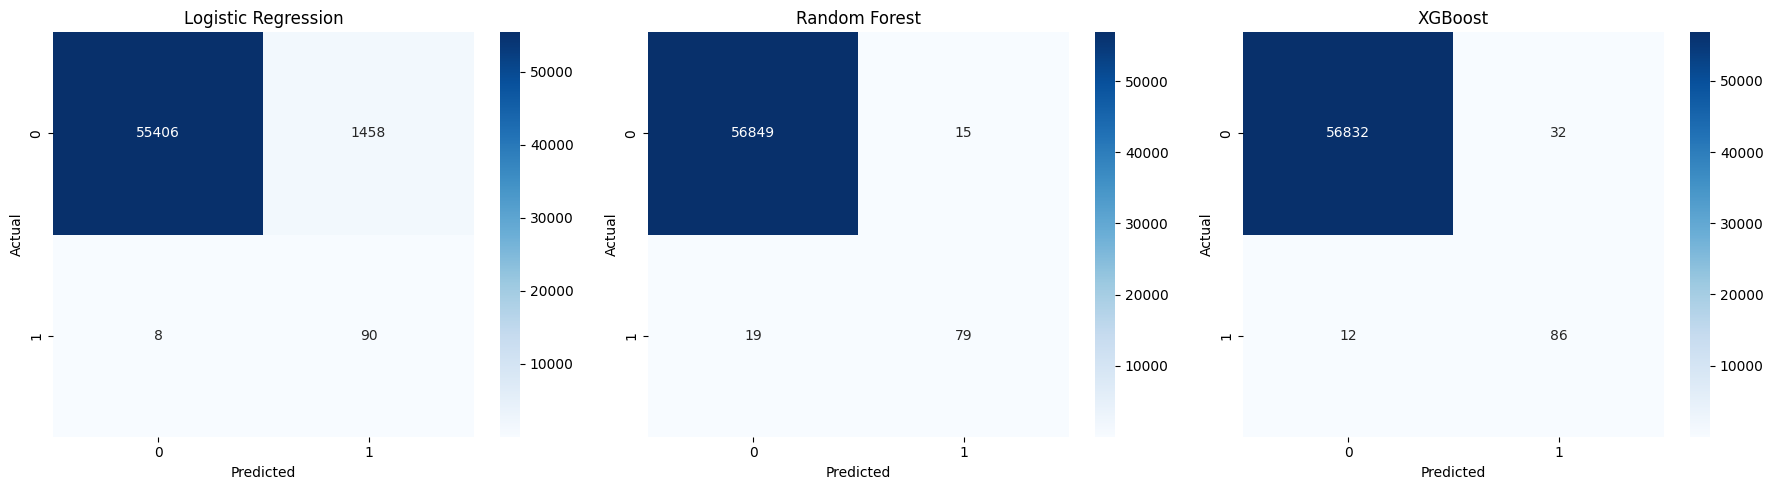

In [56]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb_tuned)
]

for ax, (name, preds) in zip(axes, models):

    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

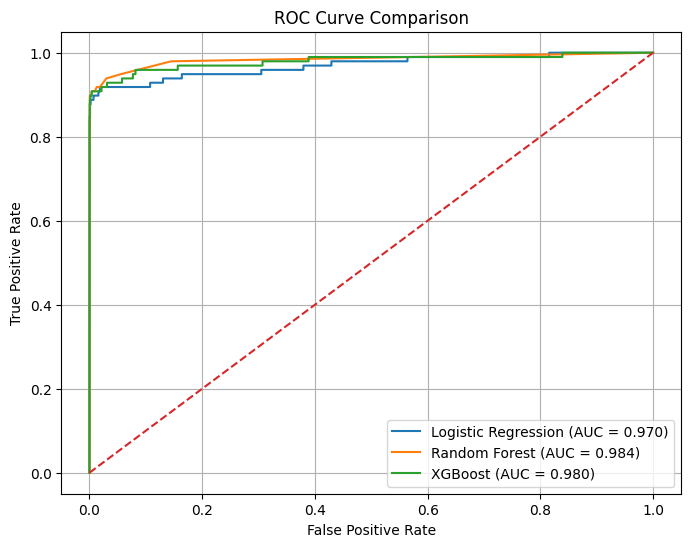

In [58]:
from sklearn.metrics import roc_curve, auc
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_tuned)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [59]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
13,V14,0.646324
3,V4,0.051346
11,V12,0.041002
7,V8,0.023776
12,V13,0.014430
17,V18,0.014254
25,V26,0.014062
9,V10,0.012698
24,V25,0.012016
0,V1,0.011901


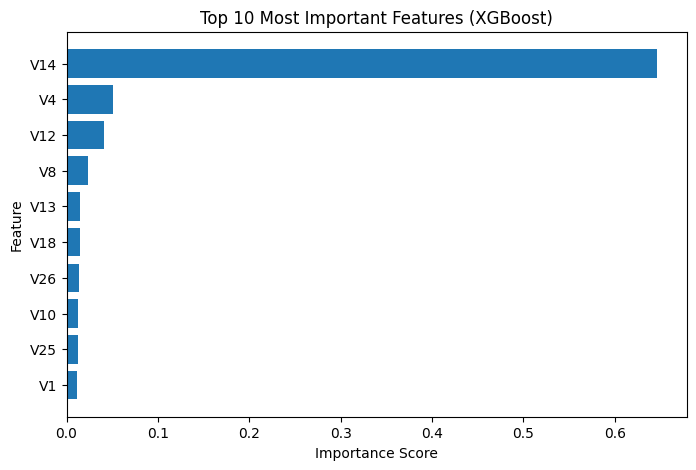

In [60]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'][::-1],
    top10['Importance'][::-1]
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features (XGBoost)')

plt.show()

In [61]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:

    preds = (y_prob_xgb_tuned >= threshold).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\nThreshold = {threshold}")
    print(f"Precision = {precision:.4f}")
    print(f"Recall    = {recall:.4f}")
    print(f"F1 Score  = {f1:.4f}")


Threshold = 0.3
Precision = 0.6350
Recall    = 0.8878
F1 Score  = 0.7404

Threshold = 0.5
Precision = 0.7288
Recall    = 0.8776
F1 Score  = 0.7963

Threshold = 0.7
Precision = 0.8077
Recall    = 0.8571
F1 Score  = 0.8317


# Conclusion

Random Forest achieved the strongest overall default performance with the highest AUC-ROC score (0.9841) and an F1-score of 0.8229. After threshold optimization, XGBoost achieved the best F1-score (0.8317), demonstrating the importance of threshold selection in fraud detection systems. Feature importance analysis identified V14, V12, and V10 as key predictors of fraudulent activity.